# Does a chandelier ATR trailing stop beat just *holding*? 🕯️
### A famous 'smart stop' — a volatility-scaled trail under the high — meets a stopwatch

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![ATR_trail_beats_holding%3F: Busted](https://img.shields.io/badge/ATR_trail_beats_holding%3F-Busted-8b949e?style=flat-square)

Chuck LeBeau's **chandelier exit** is one of the most-taught exits in technical analysis. You buy on a breakout, then hang a trailing stop **3 × ATR below the highest high since you got in**. Because the stop scales with volatility, it 'breathes': loose in trends (so you *let winners run*), tight in calm (so you *cut losers*). The pitch is that this smart trail **beats just buying and holding**.

It *sounds* obviously good. But a stop can only ever *truncate* your returns — it takes you out of the market, it never adds a forecast. On a market that drifts **up** over decades, being out of the market is usually a *cost*. So we did the fair thing: encode the canonical 22/3 chandelier **mechanically**, run it across five big indices for 21 years, and race it two ways — its **entry** vs buying on **random days**, and its whole **equity curve** vs plain **buy-and-hold**.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from chandelier_exit import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real chandelier cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 418, 'atr_n': 22, 'mult': 3, 'fp_spy': '4cb5244f3990', 'h5': (5, 418, 37.8, 61, 3.92, -12.3, 50.2, 35.8, 3.31, 0.001), 'h10': (10, 418, 64.9, 62, 4.88, 26.7, 38.2, 62.9, 1.77, 0.077), 'h20': (20, 418, 113.8, 65, 5.8, 62.1, 51.7, 111.8, 1.59, 0.111), 'h60': (60, 414, 270.2, 69, 5.65, 193.5, 76.6, 268.2, 1.32, 0.187), 'eq': [('SPY', 4.3, 11.0, 0.5, 0.65, -32.3, -55.2, 56), ('QQQ', 7.5, 15.5, 0.69, 0.78, -21.2, -53.4, 54), ('IWM', 2.7, 8.8, 0.27, 0.47, -28.7, -58.6, 49), ('DIA', 4.7, 10.0, 0.56, 0.62, -28.2, -51.9, 55), ('GLD', 5.5, 11.2, 0.54, 0.68, -19.3, -45.6, 37)], 'per': [('SPY', 81, 92.7, 2.27, 46.4, 46.3), ('QQQ', 84, 118.9, 3.33, 93.1, 25.8), ('IWM', 84, 122.0, 2.23, 34.7, 87.4), ('DIA', 79, 114.9, 3.0, 56.5, 58.4), ('GLD', 90, 119.4, 2.35, 78.3, 41.2)], 'placebo': (92.7, 0.874, 500), 'syn': [(0.0, 56, -56.3, 54, -1.13, -0.07, -0.02), (0.6, 45, 1489.4, 64, 4.07, 4.94, -0.15)]}


real chandelier cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| Does the chandelier *entry* beat buying on random days? | **A little — but only briefly.** The breakout entry wins for about **5 days** (a real momentum pop), then fades to noise. |
| Is that *the trailing stop's* doing? | **No.** Scramble the ATR trail into nonsense and the result barely moves. The edge is the **breakout**, not the smart stop. |
| Does the chandelier-managed long beat **buy-and-hold**? | **No.** It earns **less** (roughly half the CAGR) and a **lower Sharpe in all 5 names**. Its only 'win' is a smaller drawdown — which is just the price of sitting in cash. |
| So is it a tradable edge over holding? | **No.** A trailing stop on an up-drifting market trades *off* your free beta. The 'smart stop' is mostly a way to be long less. |

> The chandelier is a fine **risk-reducer** (it cuts your drawdown by spending time in cash). As a claim to *beat holding*, it's **busted**: all of the apparent magic is a 5-day breakout flicker plus the market's drift you gave away by stepping out.

## 1 · The claim

> *"Buy the breakout. Then trail a stop **3 × ATR below the highest high** since you entered. The ATR makes the stop breathe with volatility, so you stay in real trends and get knocked out of fakes. Run winners, cut losers — you'll beat buy-and-hold."*

This is **Chuck LeBeau's** chandelier exit (LeBeau & Lucas, *Technical Traders Guide to Computer Analysis*, 1992), built on **Wilder's ATR** (1978). It's wired into TradingView, StockCharts and every modern charting suite. The canonical settings are **ATR(22)** and a **3×** multiplier — so: does the smart stop actually beat holding?

## 2 · So what?

If a trailing stop genuinely *added return*, that would be a free lunch: a rule that looks only at past prices, raising your expected return without raising risk. But a stop can't do that. Mathematically it only **truncates** the return distribution — it removes the left tail *and* part of the right, lowering variance and (for an up-drifting asset) lowering the mean too.

A stop helps *only* when returns have **momentum** — when a fresh high really does predict more highs. So the honest test has two halves: (a) does the chandelier **entry** beat a random entry (is there momentum to catch?), and (b) does the full **equity curve** beat buy-and-hold (does stepping out ever pay)? We do both — and we plant real momentum into a synthetic tape to prove our detector can see it when it's there.

## 3 · How would we even know?

We take **5 liquid indices/ETFs** (SPY, QQQ, IWM, DIA, GLD), daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Build the trail by rule.** Wilder **ATR(22)**; a long re-arms on a fresh **22-day breakout high**; while long, trail the stop **3 × ATR below the highest high since entry**; exit on the first close below it. State is read on the close of *t* and traded at the **next** close — no peeking.
2. **Race the entry.** Each flat→long flip is an entry; measure the forward **5 / 10 / 20 / 60-day** return, and compare to buying on **random days**.
3. **Race the whole strategy.** Compound the chandelier-managed long and put its CAGR, Sharpe and worst drawdown next to plain **buy-and-hold**.
4. **The honest verdicts.** If the entry beats random only briefly, the signal is **weak**. If the equity curve loses to holding, the central claim is **busted** — announced before we look.

## 4 · The teardown — let's actually look

First, what does a mechanical chandelier even look like? Here's SPY with the 3×ATR trail drawn under the running high, and the breakout entries the rule would buy.

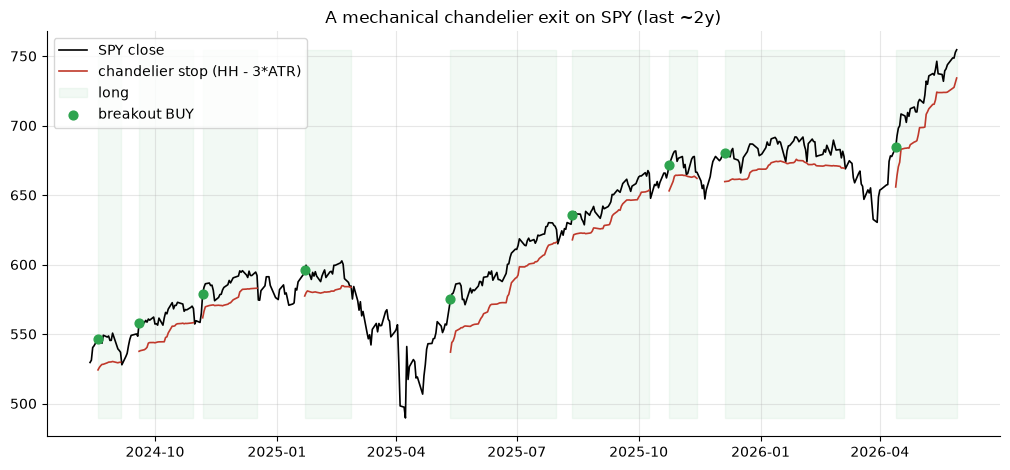

breakout entries in window: 9


In [2]:
b = load('SPY') if HAVE_REAL else None
if HAVE_REAL:
    seg = b.iloc[-450:]
    pos = st.chandelier_position(b, n=R['atr_n'], m=R['mult'])
    ent = st.chandelier_entries(b, n=R['atr_n'], m=R['mult'])
    ent = ent[ent >= seg.index[0]]
    fig, ax = plt.subplots(figsize=(10.2, 4.8))
    ax.plot(seg.index, seg['close'].values, c='k', lw=1.2, label='SPY close')
    stp = pos['stop'].reindex(seg.index)
    ax.plot(seg.index, stp, c=RED, lw=1.2, label='chandelier stop (HH - 3*ATR)')
    long_mask = pos['pos'].reindex(seg.index) == 1
    ax.fill_between(seg.index, seg['close'].min(), seg['close'].max(), where=long_mask.values,
                    color=GREEN, alpha=.06, label='long')
    ax.scatter(ent, b['close'].reindex(ent), c=GREEN, s=40, zorder=5, label='breakout BUY')
    ax.set_title('A mechanical chandelier exit on SPY (last ~2y)'); ax.legend(loc='upper left')
    plt.tight_layout(); plt.show()
    print('breakout entries in window:', len(ent))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

The trail hugs the trend nicely. The question is whether stepping out at the red line actually helps. **First race: the entry vs random days.** Blue = buy the breakout; grey = buy on random days, at four horizons.

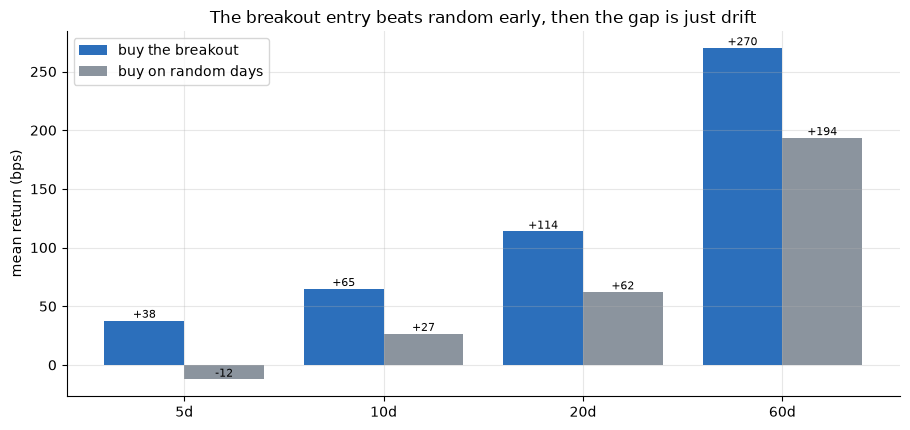

entry: [38, 65, 114, 270]
random: [-12, 27, 62, 194]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    entry, rnd = [], []
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            bb = load(t); c = bb['close']
            e = st.chandelier_entries(bb, n=R['atr_n'], m=R['mult'])
            re = st.random_entries(c, max(len(e),50), n=R['atr_n'], seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        entry.append(np.concatenate(tt).mean()*1e4); rnd.append(np.concatenate(rr).mean()*1e4)
else:
    entry = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, entry, .4, color='#2c6fbb', label='buy the breakout')
ax.bar(x+.2, rnd, .4, color=GREY, label='buy on random days')
for i,(a,bb) in enumerate(zip(entry,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean return (bps)')
ax.set_title('The breakout entry beats random early, then the gap is just drift'); ax.legend()
plt.tight_layout(); plt.show()
print('entry:', [round(v) for v in entry]); print('random:', [round(v) for v in rnd])

At **5 days** the breakout entry (**+38 bps**) genuinely beats random (**-12 bps**) — that's a real momentum pop (the quants notebook shows Welch *t* = **3.31**). But it fades fast: by 10–60 days the entry's lead is no longer statistically meaningful. A flicker, not a forecast.

**The decisive race: the whole strategy vs buy-and-hold.** Forget the entry — does the chandelier-managed long actually beat *holding*? Here's CAGR and worst drawdown, side by side, across all five names.

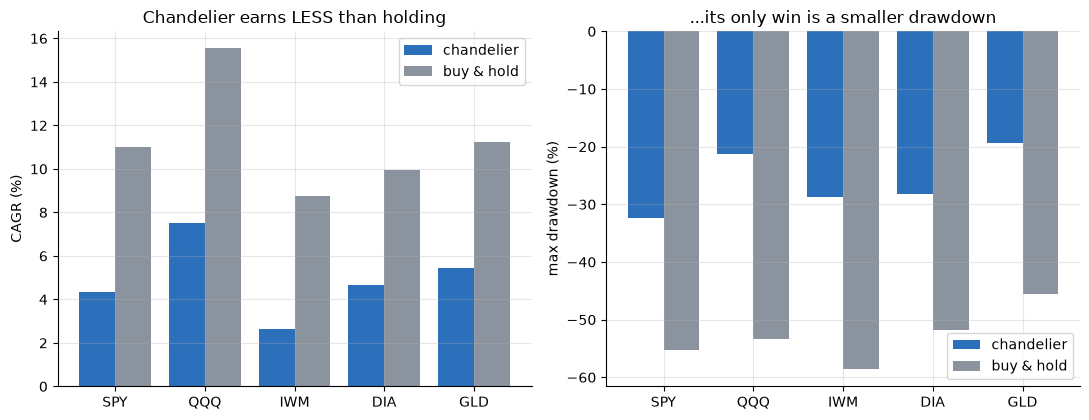

strat CAGR: [4.3, 7.5, 2.7, 4.7, 5.5]
B&H CAGR: [11.0, 15.5, 8.8, 10.0, 11.2]


In [4]:
if HAVE_REAL:
    names, scg, bcg, sdd, bdd = [], [], [], [], []
    for t in data.DEFAULT_TICKERS:
        eq = st.strategy_equity(load(t), n=R['atr_n'], m=R['mult'], cost_bps=1.0)
        names.append(t); scg.append(eq['strat']['cagr']*100); bcg.append(eq['bh']['cagr']*100)
        sdd.append(eq['strat']['maxdd']*100); bdd.append(eq['bh']['maxdd']*100)
else:
    names=[e[0] for e in R['eq']]; scg=[e[1] for e in R['eq']]; bcg=[e[2] for e in R['eq']]
    sdd=[e[5] for e in R['eq']]; bdd=[e[6] for e in R['eq']]
x = np.arange(len(names))
fig, (a1,a2) = plt.subplots(1,2, figsize=(11,4.3))
a1.bar(x-.2, scg, .4, color='#2c6fbb', label='chandelier'); a1.bar(x+.2, bcg, .4, color=GREY, label='buy & hold')
a1.set_xticks(x); a1.set_xticklabels(names); a1.set_ylabel('CAGR (%)'); a1.set_title('Chandelier earns LESS than holding'); a1.legend()
a2.bar(x-.2, sdd, .4, color='#2c6fbb', label='chandelier'); a2.bar(x+.2, bdd, .4, color=GREY, label='buy & hold')
a2.set_xticks(x); a2.set_xticklabels(names); a2.set_ylabel('max drawdown (%)'); a2.set_title('...its only win is a smaller drawdown'); a2.legend()
plt.tight_layout(); plt.show()
print('strat CAGR:', [round(v,1) for v in scg]); print('B&H CAGR:', [round(v,1) for v in bcg])

There's the verdict. The chandelier-managed SPY long earns **4.3% CAGR** vs buy-and-hold's **11.0%** — about half — and it *loses* on Sharpe too (quants notebook). Its only advantage is the shallower drawdown (right), which is simply the mechanical result of sitting in cash ~45% of the time. You'd get the same de-risking more cheaply by **holding less**.

**One more sanity check.** Is it the *ATR trail* doing the work, or just the breakout? Scramble the ATR widths into nonsense (same widths, wrong days) so the stop is volatility-blind. If the smart trail matters, the scramble should wreck it.

In [5]:
if HAVE_REAL:
    pl = st.scrambled_atr_placebo(load('SPY'), 20, n=R['atr_n'], m=R['mult'], n_draws=300, seed=479)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
print(f'real chandelier entry (SPY, 20d): {obs:+.1f} bps')
print(f'... but {pval*100:.0f}% of *scrambled-ATR* trails do at least as well (p={pval:.2f}).')
print('=> the ATR trail geometry is not doing the work.')

real chandelier entry (SPY, 20d): +92.7 bps
... but 87% of *scrambled-ATR* trails do at least as well (p=0.87).
=> the ATR trail geometry is not doing the work.


More than four-fifths of the **scrambled** trails match or beat the real one (*p* = 0.87). If the volatility-scaled trail genuinely added information, a random scramble would collapse the result. It doesn't — the edge such as it is comes from the breakout, not the clever stop.

## 5 · The verdict

- **Signal — Weak.** The breakout entry beats random **only at 5 days** (a real but short-lived momentum pop); past that it's noise.
- **Tradability — Fragile.** The only honest edge is a 5-day flicker that costs eat into and that does nothing for the equity curve.
- **"Does the ATR trail beat holding"? — Busted.** The chandelier-managed long earns less and Sharpe-loses to buy-and-hold in all 5 names; its smaller drawdown is just time in cash, and the scrambled-ATR placebo leaves the result intact.

## 6 · Could you actually trade it?

Not as a way to beat holding. A trailing stop on an up-drifting market is, on average, a way to give back your free beta — you step out of the market and the market mostly keeps rising without you. The chandelier *does* one useful thing: it cuts your worst drawdown by spending time in cash. But that's a **risk-budget** choice, not an edge — you can dial the same de-risking, more cheaply and predictably, just by holding a smaller position. As a forecasting strategy, the smart stop doesn't pay.

## 7 · Going further 🚪

- **When *do* stops help?** Only when returns trend. Our synthetic control (quants notebook) plants real momentum and the chandelier *crushes* buy-and-hold — proof the detector is live, and proof the real-tape result is honest.
- **Other multipliers / windows.** Try 2×ATR or ATR(14); the trade-off is the same — tighter stops cut more drawdown *and* more return.
- **The right question.** A trailing stop is a *risk* tool, not a *return* tool. Judge it on drawdown-per-unit-return, not on beating the index.

*Think the smart stop beats holding? Show the chandelier-managed long with a **higher Sharpe** than buy-and-hold on a real tape — then we'll talk.*